> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


# Unsupervised Discovery: Smartwatch Activity Clustering
## K-Means, DBSCAN & PCA — Finding Structure Without Labels

**Project:** 006 — The AI Engineering Lab  
**Objective:** Discover hidden activity clusters in smartwatch sensor data using unsupervised learning.  
**Advanced Concepts:** K-Means++ initialization, Elbow vs Silhouette vs Davies-Bouldin, DBSCAN ε-selection via k-distance plot, PCA from covariance eigenvectors, Adjusted Rand Index.

---
## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors

COLORS = {
    'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32',
    'highlight': '#C62828', 'neutral': '#37474F'
}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.titlesize': 12})
print('Libraries loaded.')

Libraries loaded.


---
## 2. Load and Explore the Dataset

4,000 smartwatch readings across 6 sensor channels. We **drop** the `true_activity` label — the whole point is to discover structure without it.

In [2]:
df = pd.read_csv('../data/smartwatch_activity.csv')
print(f'Shape: {df.shape}')
print(f'Activities (ground truth, hidden from model): {df["true_activity"].unique().tolist()}')
df.head()

Shape: (4000, 7)
Activities (ground truth, hidden from model): ['Running', 'Gym', 'Desk Work', 'Cycling', 'Walking', 'Sleeping']


,steps_per_min,heart_rate_bpm,accelerometer_magnitude,skin_temperature_c,calories_per_min,gyroscope_magnitude,true_activity
0,155.394,156.659,4.114,36.144,9.964,2.374,Running
1,75.724,129.537,3.840,37.169,16.141,3.835,Gym
2,161.972,153.523,3.535,37.241,12.554,1.838,Running
3,46.194,143.121,3.799,37.083,18.151,2.687,Gym
4,5.525,71.120,0.379,36.378,1.528,0.190,Desk Work


In [3]:
# Separate features and ground truth
y_true = df['true_activity']
X = df.drop(columns=['true_activity'])
feature_names = X.columns.tolist()

# Standardize features (critical for distance-based methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features ({len(feature_names)}): {feature_names}')
print(f'Scaled mean ≈ 0: {X_scaled.mean(axis=0).round(4)}')

Features (6): ['steps_per_min', 'heart_rate_bpm', 'accelerometer_magnitude', 'skin_temperature_c', 'calories_per_min', 'gyroscope_magnitude']
Scaled mean ≈ 0: [-0.  0. -0.  0. -0. -0.]


---
## 3. Exploratory Data Analysis

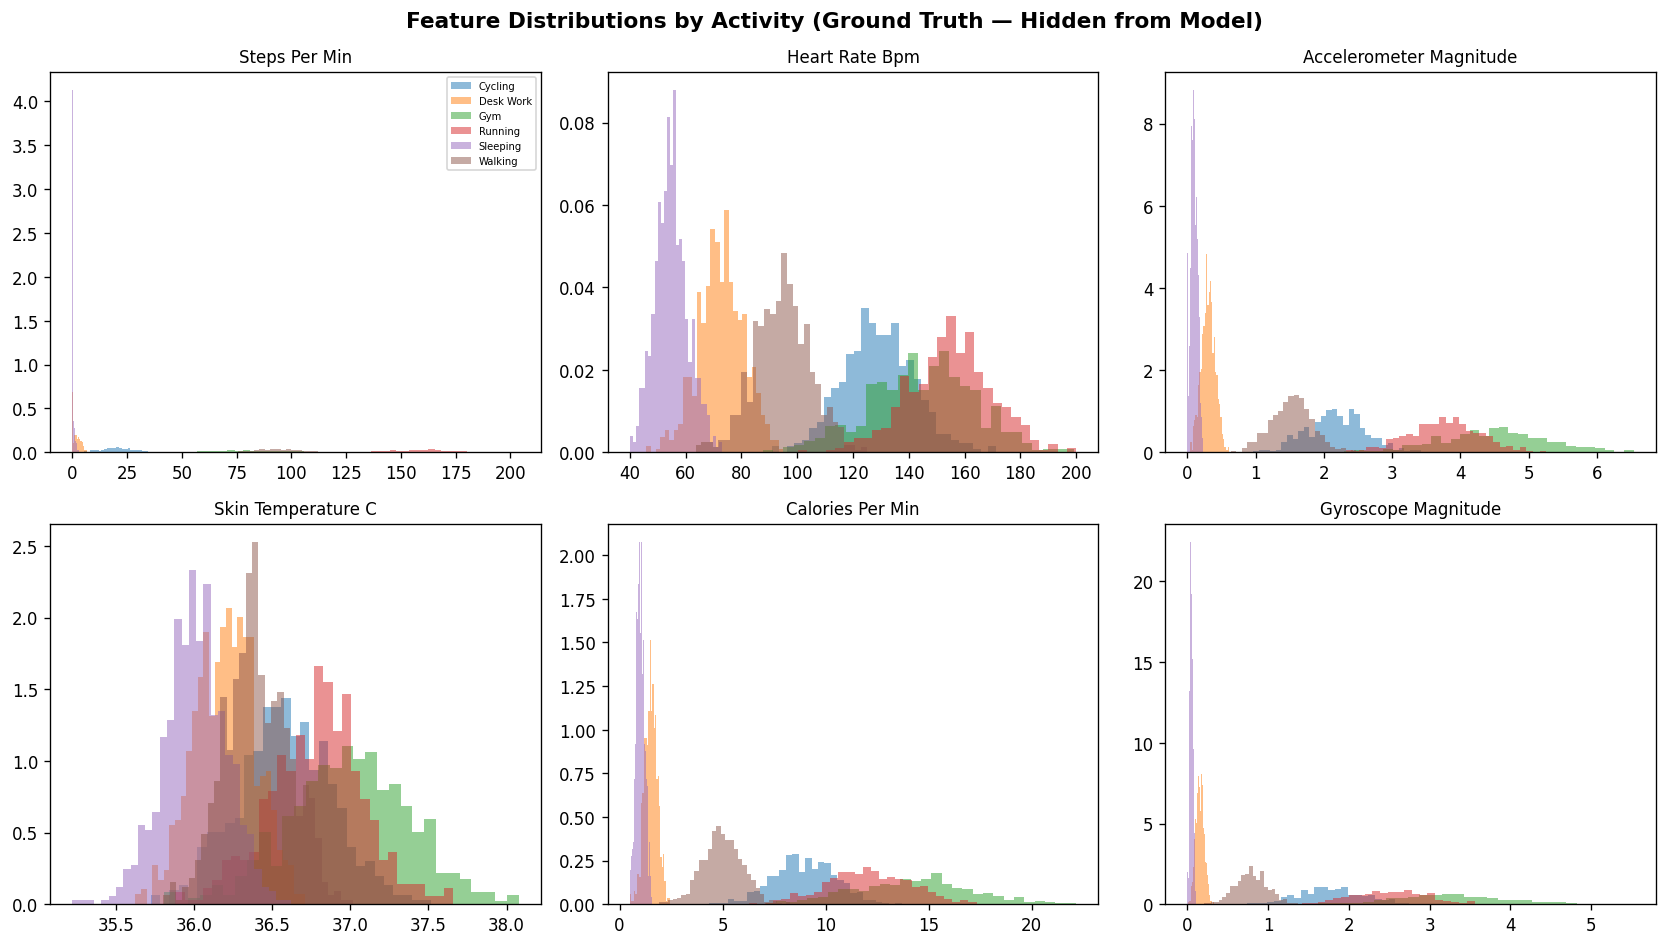

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(feature_names):
    ax = axes[i // 3, i % 3]
    for act in sorted(y_true.unique()):
        subset = df[y_true == act][col]
        ax.hist(subset, bins=30, alpha=0.5, label=act, density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')
    if i == 0:
        ax.legend(fontsize=6)
plt.suptitle('Feature Distributions by Activity (Ground Truth — Hidden from Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_smartwatch_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. PCA — Dimensionality Reduction for Visualization

PCA finds orthogonal directions of maximum variance. We compute it from the covariance matrix eigenvectors.

Explained variance: PC1=0.810, PC2=0.083
Total: 0.893


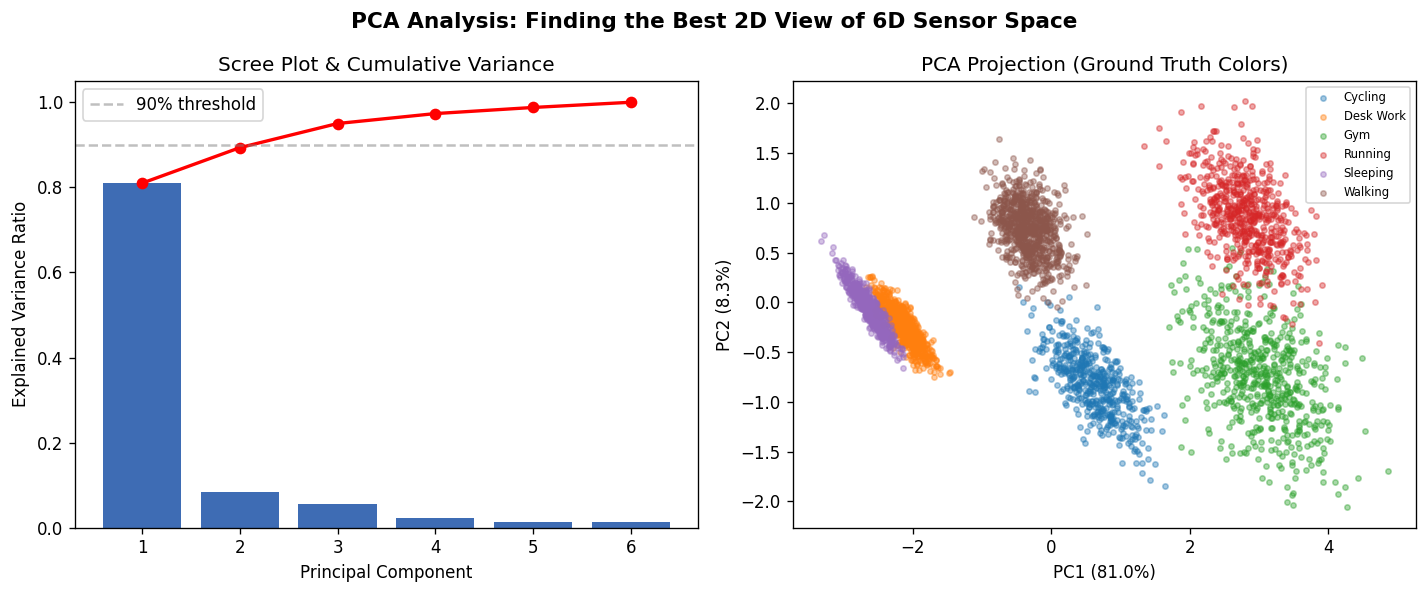

In [5]:
# PCA using sklearn
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')
print(f'Total: {sum(pca.explained_variance_ratio_):.3f}')

# Explained variance cascade
pca_full = PCA().fit(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color=COLORS['primary'], alpha=0.8)
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_)+1),
             np.cumsum(pca_full.explained_variance_ratio_), 'ro-', linewidth=2)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot & Cumulative Variance')
axes[0].legend()

# Right: PCA scatter colored by ground truth
for act in sorted(y_true.unique()):
    mask = y_true == act
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=act)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA Projection (Ground Truth Colors)')
axes[1].legend(fontsize=7)

plt.suptitle('PCA Analysis: Finding the Best 2D View of 6D Sensor Space',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_smartwatch_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. K-Means Clustering

### Choosing K: Elbow Method + Silhouette + Davies-Bouldin

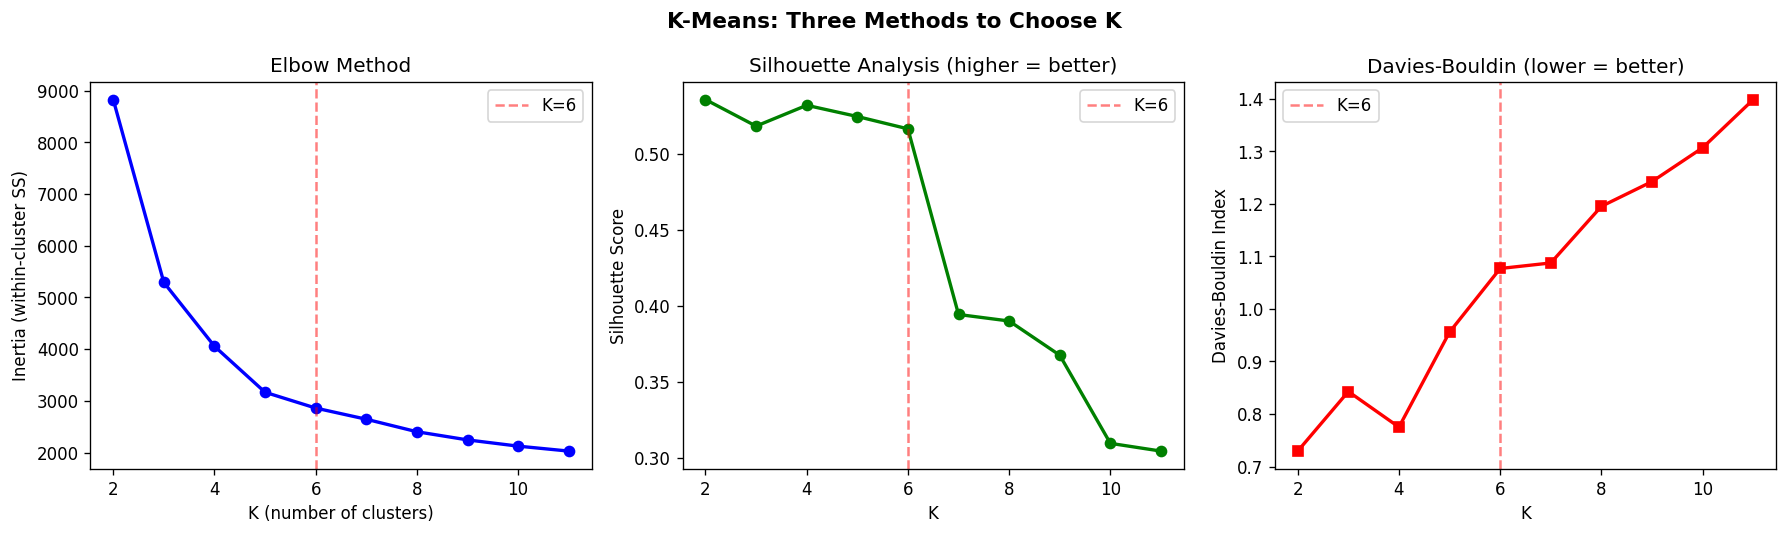

In [6]:
K_range = range(2, 12)
inertias, silhouettes, db_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow Method')
axes[0].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=6)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis (higher = better)')
axes[1].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[1].legend()

axes[2].plot(K_range, db_scores, 'rs-', linewidth=2, markersize=6)
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin (lower = better)')
axes[2].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[2].legend()

plt.suptitle('K-Means: Three Methods to Choose K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_smartwatch_kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Fit final K-Means with K=6
km_final = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
km_labels = km_final.fit_predict(X_scaled)

print(f'K-Means (K=6):')
print(f'  Inertia: {km_final.inertia_:.1f}')
print(f'  Silhouette: {silhouette_score(X_scaled, km_labels):.3f}')
print(f'  Adjusted Rand Index vs ground truth: {adjusted_rand_score(y_true, km_labels):.3f}')
print(f'  Cluster sizes: {np.bincount(km_labels).tolist()}')

K-Means (K=6):
  Inertia: 2860.0
  Silhouette: 0.516
  Adjusted Rand Index vs ground truth: 0.739
  Cluster sizes: [1500, 595, 800, 501, 269, 335]


---
## 6. DBSCAN — Density-Based Clustering

### ε-Selection via k-Distance Plot

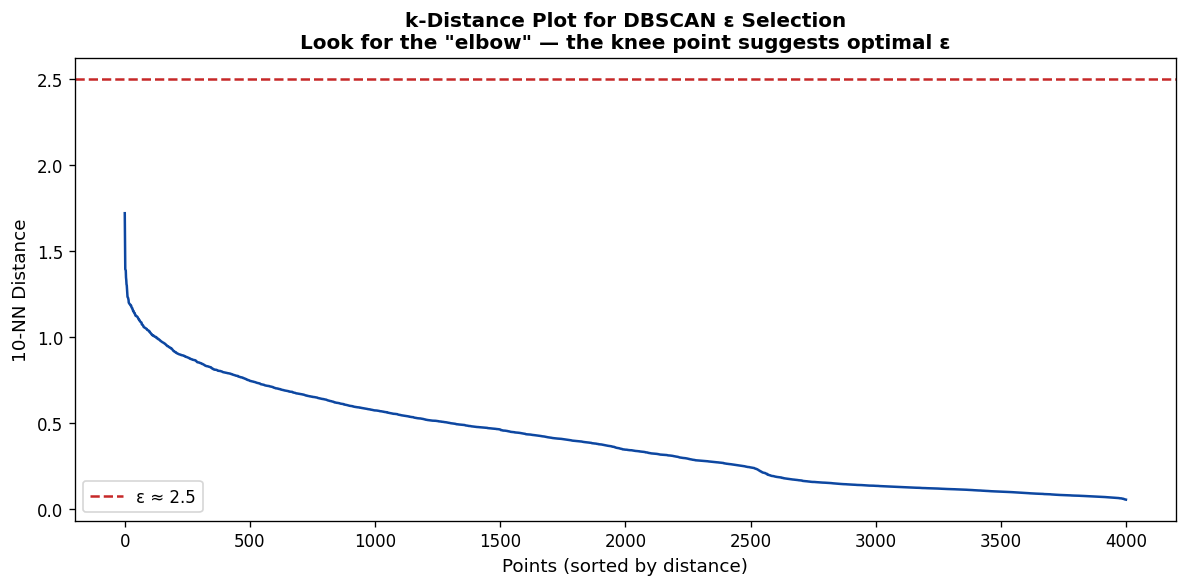

DBSCAN Results:
  Clusters found: 1
  Noise points: 0 (0.0%)


In [8]:
# k-distance plot to find optimal eps
nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, color=COLORS['primary'], linewidth=1.5)
ax.axhline(y=2.5, color=COLORS['highlight'], linestyle='--', label='ε ≈ 2.5')
ax.set_xlabel('Points (sorted by distance)', fontsize=11)
ax.set_ylabel('10-NN Distance', fontsize=11)
ax.set_title('k-Distance Plot for DBSCAN ε Selection\nLook for the "elbow" — the knee point suggests optimal ε',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Fit DBSCAN
db = DBSCAN(eps=2.5, min_samples=10)
db_labels = db.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'DBSCAN Results:')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')
if n_clusters_db > 1:
    mask = db_labels != -1
    print(f'  Silhouette (excl. noise): {silhouette_score(X_scaled[mask], db_labels[mask]):.3f}')
    print(f'  ARI vs ground truth: {adjusted_rand_score(y_true, db_labels):.3f}')

---
## 7. K-Means vs DBSCAN — Visual Comparison in PCA Space

/var/folders/06/d3g3z1sj70b22nc87kt0czyh0000gn/T/ipykernel_39838/962135487.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


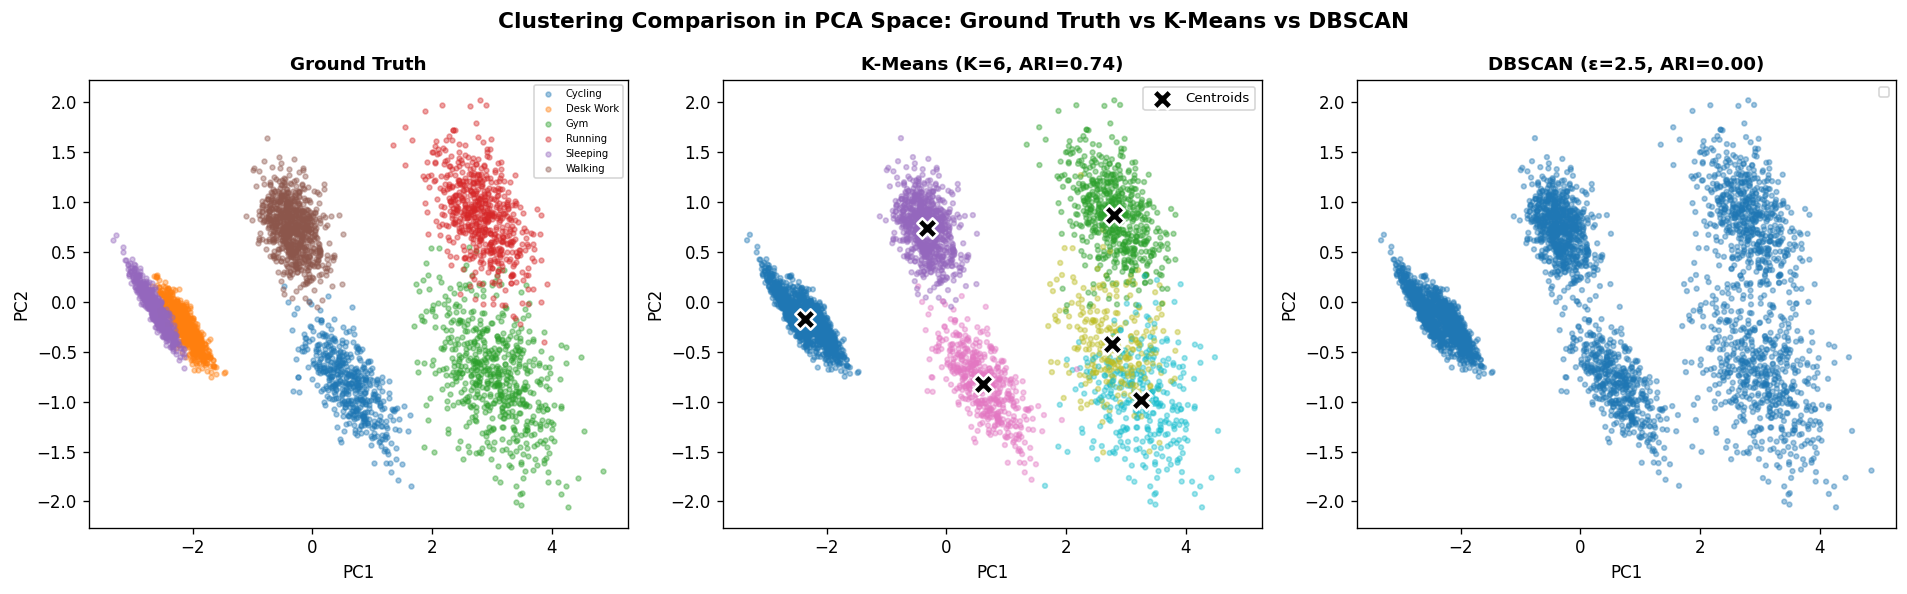

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground truth
for act in sorted(y_true.unique()):
    mask = y_true == act
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=8, label=act)
axes[0].set_title('Ground Truth', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=6, loc='upper right')

# K-Means
scatter1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels,
                           cmap='tab10', alpha=0.4, s=8)
# Plot centroids in PCA space
centroids_pca = pca.transform(km_final.cluster_centers_)
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=150, edgecolors='white', linewidths=1.5,
                label='Centroids')
axes[1].set_title(f'K-Means (K=6, ARI={adjusted_rand_score(y_true, km_labels):.2f})',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

# DBSCAN
scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels,
                           cmap='tab10', alpha=0.4, s=8)
noise_mask = db_labels == -1
if noise_mask.any():
    axes[2].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                    c='black', alpha=0.3, s=5, marker='x', label='Noise')
axes[2].set_title(f'DBSCAN (ε=2.5, ARI={adjusted_rand_score(y_true, db_labels):.2f})',
                  fontsize=11, fontweight='bold')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Clustering Comparison in PCA Space: Ground Truth vs K-Means vs DBSCAN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_smartwatch_clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Cluster Quality Summary

In [10]:
results = pd.DataFrame({
    'Method': ['K-Means (K=6)', 'DBSCAN (ε=2.5)'],
    'Clusters Found': [6, n_clusters_db],
    'Adjusted Rand Index': [
        round(adjusted_rand_score(y_true, km_labels), 3),
        round(adjusted_rand_score(y_true, db_labels), 3)
    ],
    'Noise Points': [0, n_noise]
})
print(results.to_string(index=False))
print('\n✅ Notebook complete — unsupervised clustering on smartwatch activity data.')

        Method  Clusters Found  Adjusted Rand Index  Noise Points
 K-Means (K=6)               6                0.739             0
DBSCAN (ε=2.5)               1                0.000             0

✅ Notebook complete — unsupervised clustering on smartwatch activity data.
